<a href="https://colab.research.google.com/github/Yi-LingT/Analytics-Projects/blob/main/superstore_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load raw data**

In [ ]:
import pandas as pd
import numpy as np
import os

# File path (your file is in root directory)
PATH = "/content/Sample - Superstore.csv"

In [ ]:


# Load CSV (parse dates automatically)
for enc in ['utf-8', 'latin1', 'cp1252', 'ISO-8859-1', 'gb18030']:
    try:
        df_test = pd.read_csv(PATH, encoding=enc, nrows=5)
        print(f"✅ Successfully read the file using encoding: {enc}")
        break
    except Exception:
        print(f"❌ Failed with encoding: {enc}")


print("Shape:", df_raw.shape)
display(df_raw.head(3))
df_raw.info()


✅ Successfully read the file using encoding: utf-8
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

**Clean & feature engineering**

In [ ]:
df = df_raw.copy()

# Standardize column names to snake_case
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r'[^a-z0-9]+', '_', regex=True)
              .str.strip('_'))

# Keep postal_code as string to avoid losing leading zeros
if 'postal_code' in df.columns:
    df['postal_code'] = df['postal_code'].astype('string')

# Remove duplicates (prefer row_id if exists, otherwise use order_id+product_id+sales)
before = len(df)
subset_keys = ['row_id'] if 'row_id' in df.columns else [c for c in ['order_id','product_id','sales'] if c in df.columns]
df = df.drop_duplicates(subset=subset_keys) if subset_keys else df.drop_duplicates()
print(f"Dedup: {before} -> {len(df)} rows")

# Ensure shipping date is not earlier than order date
bad_dates = (df['ship_date'] < df['order_date'])
print("bad ship_date count:", bad_dates.sum())
df = df[~bad_dates].copy()

# Ensure discount is within [0,1] and flag out-of-range values
if 'discount' in df.columns:
    df['discount_flag_out_of_range'] = (~df['discount'].between(0,1)).astype(int)
    df['discount'] = df['discount'].clip(0,1)

# Ensure quantity >= 1, replace invalid values with median
if 'quantity' in df.columns:
    df.loc[df['quantity'] <= 0, 'quantity'] = np.nan
    df['quantity'] = df['quantity'].fillna(df['quantity'].median())

# Drop rows with missing values in key columns
key_cols = [c for c in ['order_id','order_date','ship_date','sales','profit'] if c in df.columns]
df = df.dropna(subset=key_cols)

# --- Feature Engineering ---
# Delivery days
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days.clip(lower=0)

# Profit margin
df['profit_margin'] = np.where(df['sales'] > 0, df['profit'] / df['sales'], np.nan)

# Time dimensions
df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.to_period('M').astype(str)
df['order_quarter'] = df['order_date'].dt.to_period('Q').astype(str)
df['weekday']       = df['order_date'].dt.day_name()

# SLA mapping:
# Define SLA (Service Level Agreement) rules for each shipping mode
# 0 = Same Day (must ship on the same day)
# 2 = First Class (ship within 2 days)
# 4 = Second Class (ship within 4 days)
# 7 = Standard Class (ship within 7 days)
sla_map = {'Same Day':0, 'First Class':2, 'Second Class':4, 'Standard Class':7}
if 'ship_mode' in df.columns:
    df['sla_days']  = df['ship_mode'].map(sla_map).fillna(7).astype(int)
# Mark orders that are late (actual delivery_days > allowed SLA days)
# late_flag = 1 → late delivery
# late_flag = 0 → on-time delivery
    df['late_flag'] = (df['delivery_days'] > df['sla_days']).astype(int)

# Winsorize sales & profit to reduce outlier influence
def winsorize(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return s.clip(lo, hi)

for col in ['sales','profit']:
    df[col + '_win'] = winsorize(df[col])

print("Columns:", df.columns.tolist())
print("Rows after cleaning:", len(df))


Dedup: 9994 -> 9994 rows
bad ship_date count: 0
Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'discount_flag_out_of_range', 'delivery_days', 'profit_margin', 'order_year', 'order_month', 'order_quarter', 'weekday', 'sla_days', 'late_flag', 'sales_win', 'profit_win']
Rows after cleaning: 9994


**Cell 0 — Load & Prep (robust loader)**

In [30]:
# PURPOSE: Robustly load your dataset. Prefer the cleaned file; fall back to raw CSV with minimal cleaning.
import os, math
import numpy as np
import pandas as pd

CLEAN = "/content/superstore_clean.csv"
RAW   = "/content/Sample - Superstore.csv"   # change path if your file sits elsewhere

if os.path.exists(CLEAN):
    df = pd.read_csv(CLEAN, parse_dates=["order_date","ship_date"])
else:
    df = pd.read_csv(RAW, parse_dates=["Order Date","Ship Date"], infer_datetime_format=True)
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(r'[^a-z0-9]+','_',regex=True).str.strip('_'))
    # Minimal hygiene to enable charts
    df = df[df['ship_date'] >= df['order_date']].copy()
    df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days.clip(lower=0)
    df['profit_margin'] = np.where(df['sales']>0, df['profit']/df['sales'], np.nan)
    if 'ship_mode' in df.columns:
        sla_map = {'Same Day':0, 'First Class':2, 'Second Class':4, 'Standard Class':7}
        df['sla_days']  = df['ship_mode'].map(sla_map).fillna(7).astype(int)
        df['late_flag'] = (df['delivery_days'] > df['sla_days']).astype(int)

# Create time keys
if 'order_month' not in df.columns:
    df['order_month']   = df['order_date'].dt.to_period('M').astype(str)
df['order_quarter'] = df['order_date'].dt.to_period('Q').astype(str)

OUTDIR = "/content/plots"
os.makedirs(OUTDIR, exist_ok=True)
print("Saving figures to:", OUTDIR)


Saving figures to: /content/plots


**Cell 1 — Executive KPI table (for the first slide)**

In [44]:
# PURPOSE: One-glance KPI snapshot for executives.
kpi = {
    "Total Sales": df["sales"].sum(),
    "Total Profit": df["profit"].sum(),
    "Orders": df["order_id"].nunique(),
    "Avg Order Value (AOV)": df.groupby("order_id")["sales"].sum().mean(),
    "Profit Margin (%)": 100*df["profit"].sum()/df["sales"].sum(),
    "Median Delivery Days": float(df["delivery_days"].median()) if "delivery_days" in df.columns else np.nan,
    "Late Rate (%)": 100*df.get("late_flag", pd.Series([0]*len(df))).mean()
}
kpi_df = pd.DataFrame({"Metric": list(kpi.keys()), "Value": list(kpi.values())})
kpi_df

# Format values for better readability
def format_value(val):
    if abs(val) >= 1_000_000:
        return f"${val/1_000_000:.2f}M"       # millions
    elif abs(val) >= 1_000:
        return f"${val:,.0f}"                 # thousands with comma
    elif 0 < abs(val) < 1:
        return f"{val:.2%}"                   # if fraction, show %
    else:
        return f"{val:,.2f}"

kpi_df["Value"] = kpi_df["Value"].apply(format_value)
kpi_df



,Metric,Value
0,Total Sales,$2.30M
1,Total Profit,"$286,397"
2,Orders,"$5,009"
3,Avg Order Value (AOV),458.61
4,Profit Margin (%),12.47
5,Median Delivery Days,4.00
6,Late Rate (%),10.78


***Cell 2 — Quarterly Sales with 3-Quarter Moving Average***

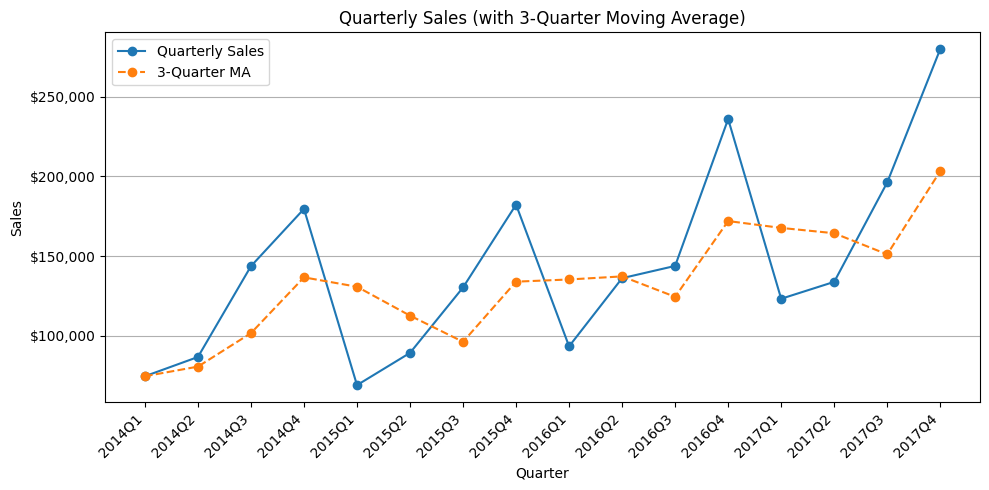

In [50]:
# PURPOSE: Reduce clutter vs monthly; moving average reveals underlying trajectory.
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def fmt_currency(x, pos):
    try: return f"${int(x):,}"
    except: return f"${x:,}"

by_q = df.groupby("order_quarter", as_index=False)["sales"].sum().sort_values("order_quarter")
by_q["MA3"] = by_q["sales"].rolling(3, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(by_q["order_quarter"], by_q["sales"], marker='o', label="Quarterly Sales")
plt.plot(by_q["order_quarter"], by_q["MA3"], marker='o', linestyle="--", label="3-Quarter MA")
plt.title("Quarterly Sales (with 3-Quarter Moving Average)")
plt.xlabel("Quarter"); plt.ylabel("Sales")
plt.gca().yaxis.set_major_formatter(FuncFormatter(fmt_currency))
plt.xticks(rotation=45, ha="right"); plt.grid(True, axis='y'); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUTDIR}/01_quarterly_sales_ma.png", dpi=180); plt.show()

#Slide note: “Sales trend is ↑/↓ over time; moving average smooths seasonality to show the underlying growth.


**Cell 3 — Profit by Category（排序+數值標註）**

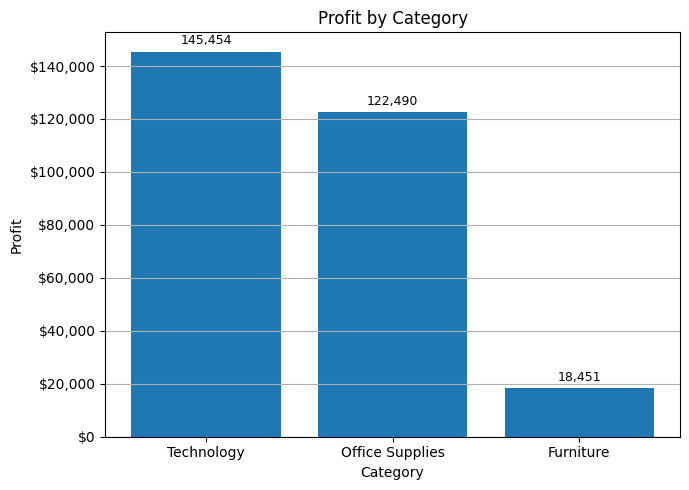

In [33]:
# PURPOSE: Fast identification of profit engines and underperformers at category level.
from matplotlib.ticker import FuncFormatter

by_cat = (df.groupby("category", as_index=False)
          .agg(profit=("profit","sum"))
          .sort_values("profit", ascending=False))

plt.figure(figsize=(7,5))
ax = plt.gca()
ax.bar(by_cat["category"], by_cat["profit"])
ax.set_title("Profit by Category")
ax.set_xlabel("Category"); ax.set_ylabel("Profit")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_currency))
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h):,}", (p.get_x()+p.get_width()/2., h),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig(f"{OUTDIR}/02_profit_by_category.png", dpi=180); plt.show()

#Slide note: “Category A drives profit; Category B lags—candidate for pricing, promo, or assortment review.”


**Cell 4 — Top 10 Sub-Categories by Profit**

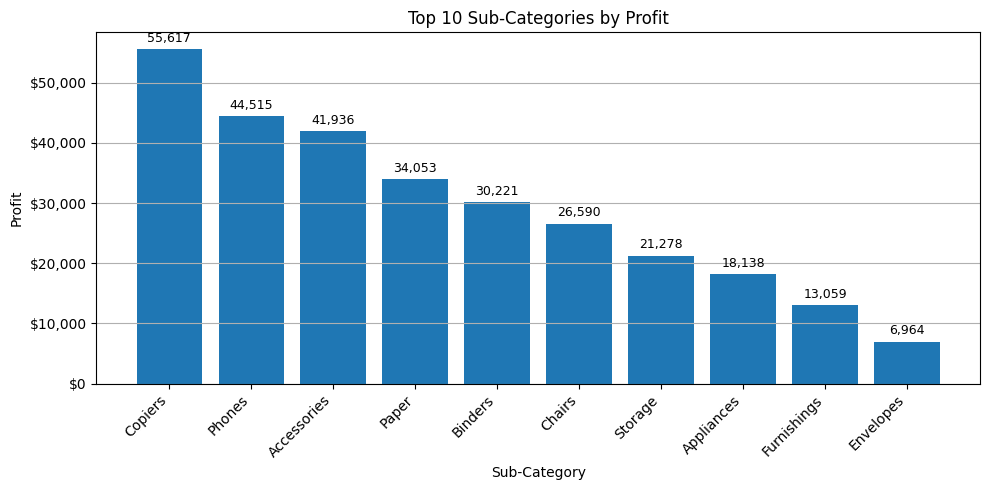

In [34]:
# PURPOSE: Move from revenue to profitability at sub-category for targeted actions.
by_sub = (df.groupby("sub_category", as_index=False)
          .agg(profit=("profit","sum"))
          .sort_values("profit", ascending=False)
          .head(10))

plt.figure(figsize=(10,5))
ax = plt.gca()
ax.bar(by_sub["sub_category"], by_sub["profit"])
ax.set_title("Top 10 Sub-Categories by Profit")
ax.set_xlabel("Sub-Category"); ax.set_ylabel("Profit")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_currency))
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h):,}", (p.get_x()+p.get_width()/2., h),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig(f"{OUTDIR}/03_top10_subcategory_profit.png", dpi=180); plt.show()

#Slide note: “Double-down on profitable sub-categories; investigate tail items for margin leakage.”


Cell 5 — Profit vs Discount (with Linear Fit)

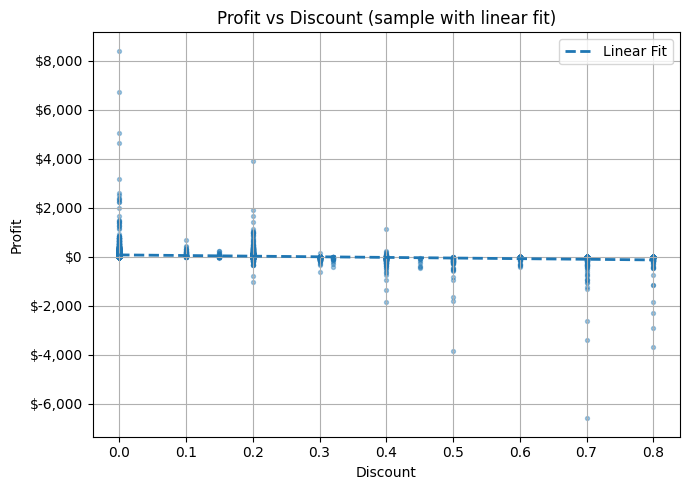

Slope: -256.48 (negative slope implies discounts reduce profit)


In [35]:
# PURPOSE: Quantify discount impact on profit; line of best fit gives direction (no fancy libs).
from matplotlib.ticker import FuncFormatter
sample = df.sample(min(8000, len(df)), random_state=42)
x = sample["discount"].values; y = sample["profit"].values
A = np.vstack([x, np.ones(len(x))]).T
slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=8, alpha=0.4)
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, slope*xs + intercept, linestyle="--", linewidth=2, label="Linear Fit")
plt.title("Profit vs Discount (sample with linear fit)")
plt.xlabel("Discount"); plt.ylabel("Profit")
plt.gca().yaxis.set_major_formatter(FuncFormatter(fmt_currency))
plt.grid(True, axis='both'); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUTDIR}/04_profit_vs_discount_linearfit.png", dpi=180); plt.show()
print("Slope:", round(slope,2), "(negative slope implies discounts reduce profit)")


#Slide note: “Negative slope → heavy discounting compresses profit; tighten discount policies on low-elastic items.”


**Cell 6 — Delivery Days Distribution with Median & P95**

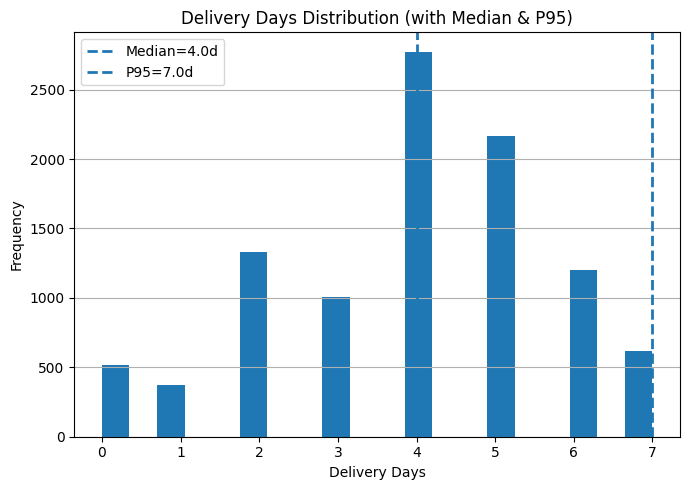

Median delivery: 4.0 days | 95th percentile: 7.0 days


In [36]:
# PURPOSE: Show typical lead-time and tail risk for operations.
p50 = df["delivery_days"].median()
p95 = df["delivery_days"].quantile(0.95)

plt.figure(figsize=(7,5))
plt.hist(df["delivery_days"].dropna(), bins=20)
plt.axvline(p50, linestyle="--", linewidth=2, label=f"Median={p50:.1f}d")
plt.axvline(p95, linestyle="--", linewidth=2, label=f"P95={p95:.1f}d")
plt.title("Delivery Days Distribution (with Median & P95)")
plt.xlabel("Delivery Days"); plt.ylabel("Frequency")
plt.grid(True, axis='y'); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUTDIR}/05_delivery_days_distribution.png", dpi=180); plt.show()
print(f"Median delivery: {p50:.1f} days | 95th percentile: {p95:.1f} days")

#Slide note : “Keep median low; compress P95 by fixing long tail (carrier SLA, ship-mode mix, fulfillment bottlenecks).”

**Cell 7 — Late Rate by Ship Mode**

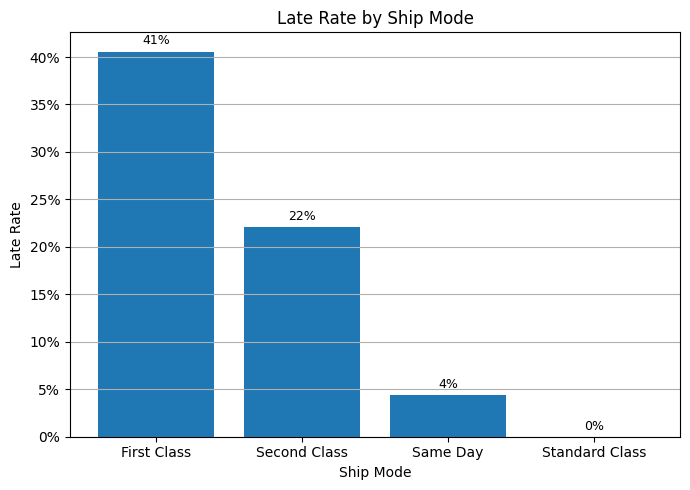

,ship_mode,late_rate,median_delivery
0,First Class,0.405722,2.0
2,Second Class,0.220566,3.0
1,Same Day,0.044199,0.0
3,Standard Class,0.000000,5.0


In [42]:
# PURPOSE: Pinpoint late-shipment hotspots by transport mode.
from matplotlib.ticker import FuncFormatter
by_ship = (df.groupby("ship_mode", as_index=False)
           .agg(late_rate=("late_flag","mean"),
                median_delivery=("delivery_days","median"))
           .sort_values("late_rate", ascending=False))

plt.figure(figsize=(7,5))
ax = plt.gca()
ax.bar(by_ship["ship_mode"], by_ship["late_rate"])
ax.set_title("Late Rate by Ship Mode")
ax.set_xlabel("Ship Mode"); ax.set_ylabel("Late Rate")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: f"{x:.0%}"))
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h*100:.0f}%", (p.get_x()+p.get_width()/2., h),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig(f"{OUTDIR}/06_late_rate_by_shipmode.png", dpi=180); plt.show()
by_ship

#Slide note: “Target high-late modes for SLA renegotiation or inventory positioning; consider shifting mix to low-late modes.”


**Cell 8 — Profit by Region（地區佈局的快照）**

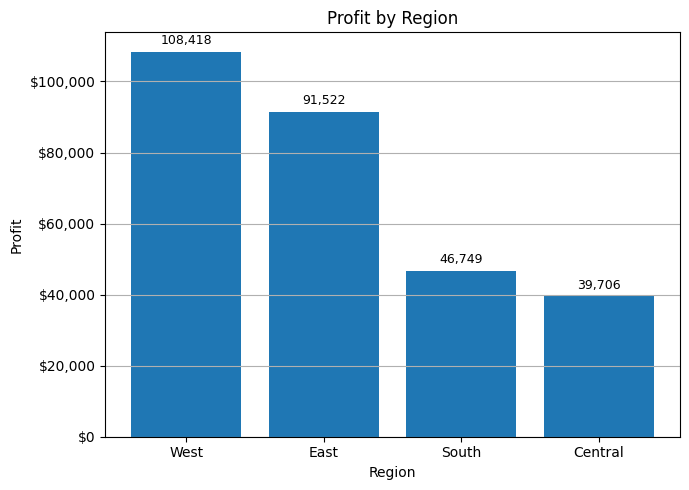

,region,profit
3,West,108418.4489
1,East,91522.7800
2,South,46749.4303
0,Central,39706.3625


In [38]:
# PURPOSE: Show where to expand or retrench geographically.
from matplotlib.ticker import FuncFormatter

by_region = (df.groupby("region", as_index=False)
             .agg(profit=("profit","sum"))
             .sort_values("profit", ascending=False))

plt.figure(figsize=(7,5))
ax = plt.gca()
ax.bar(by_region["region"], by_region["profit"])
ax.set_title("Profit by Region")
ax.set_xlabel("Region"); ax.set_ylabel("Profit")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_currency))
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h):,}", (p.get_x()+p.get_width()/2., h),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig(f"{OUTDIR}/07_profit_by_region.png", dpi=180); plt.show()
by_region

#Slide note: “Invest in top-profit regions; diagnose bottom regions (pricing, shipping costs, product-market fit).”


**Cell 9 — Average Order Value by Segment**

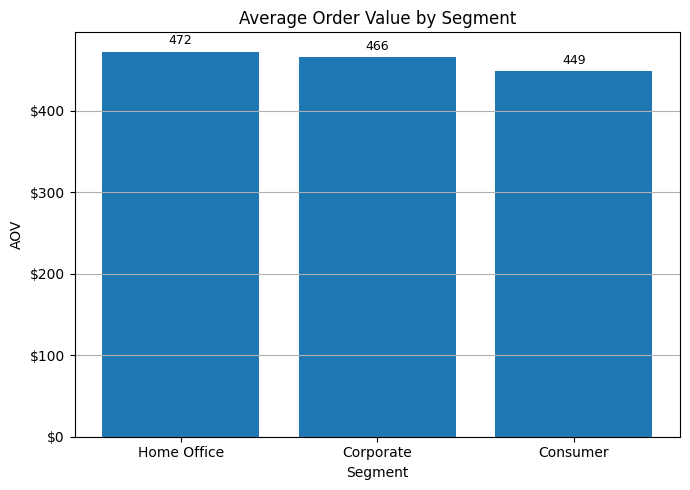

,segment,AOV
2,Home Office,472.665730
1,Corporate,466.411075
0,Consumer,449.111116


In [39]:
# PURPOSE: Focus sales/marketing on higher value segments.
from matplotlib.ticker import FuncFormatter

aov_seg = (df.groupby("order_id", as_index=False)
             .agg(sales=("sales","sum"), segment=("segment","first")))
by_seg = (aov_seg.groupby("segment", as_index=False)["sales"].mean()
          .rename(columns={"sales":"AOV"})
          .sort_values("AOV", ascending=False))

plt.figure(figsize=(7,5))
ax = plt.gca()
ax.bar(by_seg["segment"], by_seg["AOV"])
ax.set_title("Average Order Value by Segment")
ax.set_xlabel("Segment"); ax.set_ylabel("AOV")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_currency))
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h):,}", (p.get_x()+p.get_width()/2., h),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig(f"{OUTDIR}/08_aov_by_segment.png", dpi=180); plt.show()
by_seg


#Slide note: “Prioritize the highest-AOV segment for account-based plays and upsell bundles.”

**Cell 10 — YoY Quarterly Sales**

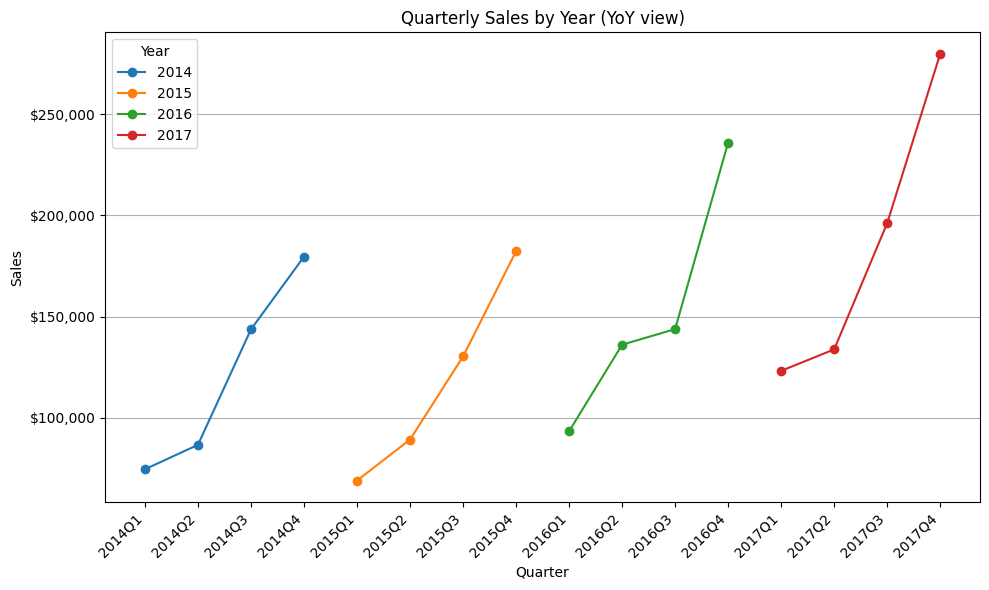

year,2014,2015,2016,2017
order_quarter,,,,
2014Q1,74447.7960,NaN,NaN,NaN
2014Q2,86538.7596,NaN,NaN,NaN
2014Q3,143633.2123,NaN,NaN,NaN
2014Q4,179627.7302,NaN,NaN,NaN
2015Q1,NaN,68851.7386,NaN,NaN
2015Q2,NaN,89124.1870,NaN,NaN
2015Q3,NaN,130259.5752,NaN,NaN
2015Q4,NaN,182297.0082,NaN,NaN
2016Q1,NaN,NaN,93237.1810,NaN


In [41]:
# PURPOSE: Clear year-over-year momentum view to support planning decisions.
from matplotlib.ticker import FuncFormatter

df["year"] = df["order_date"].dt.year
q_y = (df.groupby(["year","order_quarter"], as_index=False)["sales"].sum()
       .sort_values(["year","order_quarter"]))
pivot_qy = q_y.pivot(index="order_quarter", columns="year", values="sales")

plt.figure(figsize=(10,6))
for col in pivot_qy.columns:
    plt.plot(pivot_qy.index, pivot_qy[col], marker='o', label=str(col))
plt.title("Quarterly Sales by Year (YoY view)")
plt.xlabel("Quarter"); plt.ylabel("Sales")
plt.gca().yaxis.set_major_formatter(FuncFormatter(fmt_currency))
plt.xticks(rotation=45, ha="right"); plt.grid(True, axis='y'); plt.legend(title="Year")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/09_quarterly_sales_yoy.png", dpi=180); plt.show()
pivot_qy

#Slide note : “Identify acceleration vs slowdown vs seasonality; use for plan/forecast sanity check.""

In [45]:
!zip -r /content/superstore_plots.zip /content/plots -q
print("Zip ready: /content/superstore_plots.zip")


Zip ready: /content/superstore_plots.zip
